In [32]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [33]:
from src.dataset import get_final_data
from src.vae import VAE, train_vae
from src.clustering import run_kmeans, pca_transform
from src.evaluation import evaluate

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

import torch
import matplotlib.pyplot as plt
import pandas as pd

In [35]:
import os
import librosa
import numpy as np

def extract_mfcc(file_path):
    try:
        y, sr = librosa.load(file_path, duration=30)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        return np.mean(mfcc.T, axis=0)
    except:
        return None


features = []
names = []

audio_dir = "../data/audio"

for root, dirs, files in os.walk(audio_dir):
    folder = os.path.basename(root)

    for file in files:
        if file.endswith(".wav") or file.endswith(".au"):

            path = os.path.join(root, file)

            mfcc = extract_mfcc(path)
            if mfcc is not None:
                features.append(mfcc)

                base_name = file.replace(".wav", "").replace(".au", "")
                name = folder + "_" + base_name

                names.append(name)

X_audio = np.array(features)

print("Total audio loaded:", len(names))
print("Sample names:", names[:10])

Total audio loaded: 1061
Sample names: ['blues_blues.00000', 'blues_blues.00001', 'blues_blues.00002', 'blues_blues.00003', 'blues_blues.00004', 'blues_blues.00005', 'blues_blues.00006', 'blues_blues.00007', 'blues_blues.00008', 'blues_blues.00009']


In [4]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import librosa
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def extract_mfcc(file_path):
    try:
        y, sr = librosa.load(file_path, duration=30)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        return np.mean(mfcc.T, axis=0)
    except:
        return None


def load_audio(audio_dir, max_gtzan=150):
    features = []
    names = []
    gtzan_count = 0

    for root, dirs, files in os.walk(audio_dir):
        folder = os.path.basename(root)

        for file in files:
            if file.endswith(".wav") or file.endswith(".au"):

                # limit only GTZAN (not Rabindra)
                if "Rabindra" not in folder:
                    if gtzan_count >= max_gtzan:
                        continue
                    gtzan_count += 1

                path = os.path.join(root, file)

                mfcc = extract_mfcc(path)
                if mfcc is not None:
                    features.append(mfcc)

                    base_name = file.replace(".wav", "").replace(".au", "")
                    name = folder + "_" + base_name

                    names.append(name)

    return np.array(features), names

def load_lyrics(lyrics_dir, names):

    try:
        with open(os.path.join(lyrics_dir, "drake_lyrics.txt"), encoding="utf-8") as f:
            drake_text = f.read()
    except:
        drake_text = "music rhythm song"

    try:
        with open(os.path.join(lyrics_dir, "Rabindra_Sangeet_data.txt"), encoding="utf-8") as f:
            rabindra_text = f.read()
    except:
        rabindra_text = "bangla gaan prem kobita"

    texts = []

    for name in names:
        if "Rabindra" in name:
            texts.append(rabindra_text)
        else:
            texts.append(drake_text)

    vectorizer = TfidfVectorizer(max_features=500)
    features = vectorizer.fit_transform(texts).toarray()

    return features

def get_data(audio_dir, lyrics_dir):
    audio_features, names = load_audio(audio_dir)
    lyrics_features = load_lyrics(lyrics_dir, names)

    X = np.concatenate([audio_features, lyrics_features], axis=1)

    return X, names

X, names = get_data("../data/audio", "../data/lyrics")

print("Total songs:", len(names))
print("Feature shape:", X.shape)
print(names[:10])

Total songs: 211
Feature shape: (211, 513)
['blues_blues.00000', 'blues_blues.00001', 'blues_blues.00002', 'blues_blues.00003', 'blues_blues.00004', 'blues_blues.00005', 'blues_blues.00006', 'blues_blues.00007', 'blues_blues.00008', 'blues_blues.00009']


In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
input_dim = X.shape[1]

vae = VAE(input_dim, latent_dim=16)
vae = train_vae(vae, X, epochs=60)

Epoch 1, Loss: 151.1568603515625
Epoch 2, Loss: 78.58141326904297
Epoch 3, Loss: 56.42060852050781
Epoch 4, Loss: 52.6689338684082
Epoch 5, Loss: 36.83330535888672
Epoch 6, Loss: 26.64354705810547
Epoch 7, Loss: 21.674646377563477
Epoch 8, Loss: 17.320091247558594
Epoch 9, Loss: 15.714805603027344
Epoch 10, Loss: 17.0479736328125
Epoch 11, Loss: 16.385986328125
Epoch 12, Loss: 14.534075736999512
Epoch 13, Loss: 12.539945602416992
Epoch 14, Loss: 9.989594459533691
Epoch 15, Loss: 8.544950485229492
Epoch 16, Loss: 8.040098190307617
Epoch 17, Loss: 7.606473445892334
Epoch 18, Loss: 7.197032451629639
Epoch 19, Loss: 6.528423309326172
Epoch 20, Loss: 5.7928290367126465
Epoch 21, Loss: 5.54665994644165
Epoch 22, Loss: 5.161680221557617
Epoch 23, Loss: 4.539730548858643
Epoch 24, Loss: 3.904660224914551
Epoch 25, Loss: 3.741176128387451
Epoch 26, Loss: 3.941829204559326
Epoch 27, Loss: 3.6678736209869385
Epoch 28, Loss: 3.1769721508026123
Epoch 29, Loss: 2.995769739151001
Epoch 30, Loss: 2.99

In [7]:
vae.eval()

with torch.no_grad():
    mu, _ = vae.encode(torch.tensor(X).float())
    latent = mu.numpy()

print("Latent shape:", latent.shape)

Latent shape: (211, 16)


In [8]:
labels_vae = run_kmeans(latent, k=5)

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [9]:
X_pca = pca_transform(X, n_components=16)
labels_pca = run_kmeans(X_pca, k=5)

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [10]:
sil_vae, ch_vae = evaluate(latent, labels_vae)
sil_pca, ch_pca = evaluate(X_pca, labels_pca)

print(" RESULTS ")
print(f"VAE -> Silhouette: {sil_vae:.3f}, CH: {ch_vae:.2f}")
print(f"PCA -> Silhouette: {sil_pca:.3f}, CH: {ch_pca:.2f}")

 RESULTS 
VAE -> Silhouette: 0.093, CH: 19.88
PCA -> Silhouette: 0.277, CH: 3575.86


In [11]:
os.makedirs("../results/latent_visualization", exist_ok=True)

df = pd.DataFrame({
    "Method": ["VAE", "PCA"],
    "Silhouette": [sil_vae, sil_pca],
    "Calinski-Harabasz": [ch_vae, ch_pca]
})

df.to_csv("../results/clustering_metrics.csv", index=False)

df

,Method,Silhouette,Calinski-Harabasz
0,VAE,0.093279,19.882464
1,PCA,0.277078,3575.860300


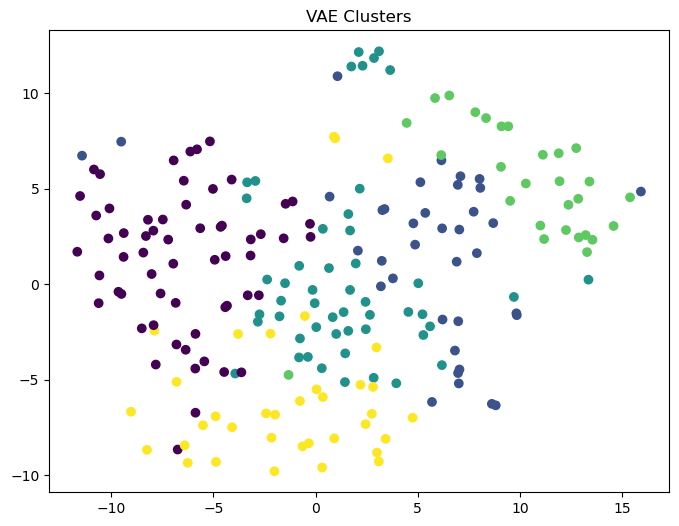

In [12]:
tsne = TSNE(n_components=2, random_state=42)

X_vis = tsne.fit_transform(latent)

plt.figure(figsize=(8,6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=labels_vae)
plt.title("VAE Clusters")
plt.savefig("../results/latent_visualization/vae_tsne.png")
plt.show()

In [14]:
import os
import librosa
import numpy as np

def extract_mfcc(file_path):
    try:
        y, sr = librosa.load(file_path, duration=30)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        return np.mean(mfcc.T, axis=0)
    except Exception as e:
        print("Error:", file_path)
        return None


audio_dir = "../data/audio"

features = []
names = []

count = 0

for root, dirs, files in os.walk(audio_dir):
    print("Checking folder:", root)   # 👈 DEBUG LINE

    for file in files:
        if file.lower().endswith((".wav", ".au")):

            path = os.path.join(root, file)

            mfcc = extract_mfcc(path)
            if mfcc is not None:
                features.append(mfcc)

                folder = os.path.basename(root)
                base_name = os.path.splitext(file)[0]

                name = folder + "_" + base_name
                names.append(name)

                count += 1

print("\n Total audio loaded:", count)
print("Sample:", names[:10])

Checking folder: ../data/audio
Checking folder: ../data/audio\blues
Checking folder: ../data/audio\classical
Checking folder: ../data/audio\country
Checking folder: ../data/audio\disco
Checking folder: ../data/audio\hiphop
Checking folder: ../data/audio\jazz
Checking folder: ../data/audio\metal
Checking folder: ../data/audio\pop
Checking folder: ../data/audio\Rabindra Sangeet
Checking folder: ../data/audio\reggae
Checking folder: ../data/audio\rock

 Total audio loaded: 1061
Sample: ['blues_blues.00000', 'blues_blues.00001', 'blues_blues.00002', 'blues_blues.00003', 'blues_blues.00004', 'blues_blues.00005', 'blues_blues.00006', 'blues_blues.00007', 'blues_blues.00008', 'blues_blues.00009']


In [17]:
import numpy as np

rabindra_idx = [i for i, n in enumerate(names) if "Rabindra" in n]
gtzan_idx = [i for i, n in enumerate(names) if "Rabindra" not in n]

np.random.seed(42)
gtzan_sample = np.random.choice(gtzan_idx, size=150, replace=False)

final_idx = list(gtzan_sample) + rabindra_idx
X_audio = np.array(features)
X_audio = X_audio[final_idx]
names = [names[i] for i in final_idx]

print("Balanced dataset size:", len(names))

Balanced dataset size: 211


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

with open("../data/lyrics/drake_lyrics.txt", encoding="utf-8") as f:
    drake_text = f.read()

with open("../data/lyrics/Rabindra_Sangeet_data.txt", encoding="utf-8") as f:
    rabindra_text = f.read()

texts = []

for name in names:
    if "Rabindra" in name:
        texts.append(rabindra_text)
    else:
        texts.append(drake_text)

vectorizer = TfidfVectorizer(max_features=500)
X_text = vectorizer.fit_transform(texts).toarray()

X = np.concatenate([X_audio, 0.2 * X_text], axis=1)

print("Final shape:", X.shape)

Final shape: (211, 513)


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

with open("../data/lyrics/drake_lyrics.txt", encoding="utf-8") as f:
    drake_text = f.read()

with open("../data/lyrics/Rabindra_Sangeet_data.txt", encoding="utf-8") as f:
    rabindra_text = f.read()

texts = []

for name in names:
    if "Rabindra" in name:
        texts.append(rabindra_text)
    else:
        texts.append(drake_text)

vectorizer = TfidfVectorizer(max_features=500)
X_text = vectorizer.fit_transform(texts).toarray()

X = np.concatenate([X_audio, 0.2 * X_text], axis=1)

print("Final shape:", X.shape)

Final shape: (211, 513)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [22]:
from sklearn.decomposition import PCA

pca_pre = PCA(n_components=50)
X_reduced = pca_pre.fit_transform(X)

In [23]:
from src.vae import VAE, train_vae

vae = VAE(input_dim=50, latent_dim=8)
vae = train_vae(vae, X_reduced, epochs=120)

Epoch 1, Loss: 621.4691162109375
Epoch 2, Loss: 468.3105163574219
Epoch 3, Loss: 348.1919860839844
Epoch 4, Loss: 256.4942626953125
Epoch 5, Loss: 186.8566131591797
Epoch 6, Loss: 133.91270446777344
Epoch 7, Loss: 94.43208312988281
Epoch 8, Loss: 66.7189712524414
Epoch 9, Loss: 49.41386413574219
Epoch 10, Loss: 41.046852111816406
Epoch 11, Loss: 39.64183807373047
Epoch 12, Loss: 42.92891311645508
Epoch 13, Loss: 48.55270004272461
Epoch 14, Loss: 54.207916259765625
Epoch 15, Loss: 58.331703186035156
Epoch 16, Loss: 60.06151580810547
Epoch 17, Loss: 59.26566696166992
Epoch 18, Loss: 56.41310119628906
Epoch 19, Loss: 51.96044158935547
Epoch 20, Loss: 46.677894592285156
Epoch 21, Loss: 41.12383270263672
Epoch 22, Loss: 35.837677001953125
Epoch 23, Loss: 31.079246520996094
Epoch 24, Loss: 27.139801025390625
Epoch 25, Loss: 23.971752166748047
Epoch 26, Loss: 21.658498764038086
Epoch 27, Loss: 20.05801773071289
Epoch 28, Loss: 19.04879379272461
Epoch 29, Loss: 18.498428344726562
Epoch 30, Los

In [24]:
import torch

vae.eval()
with torch.no_grad():
    mu, _ = vae.encode(torch.tensor(X_reduced).float())
    latent = mu.numpy()

print(latent.shape)

(211, 8)


In [25]:
from src.clustering import run_kmeans

labels_vae = run_kmeans(latent, k=4)

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [26]:
from src.clustering import pca_transform

X_pca = pca_transform(X, 16)
labels_pca = run_kmeans(X_pca, k=4)

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [27]:
from src.evaluation import evaluate

sil_vae, ch_vae = evaluate(latent, labels_vae)
sil_pca, ch_pca = evaluate(X_pca, labels_pca)

print("===== RESULTS =====")
print(f"VAE -> Silhouette: {sil_vae:.3f}, CH: {ch_vae:.2f}")
print(f"PCA -> Silhouette: {sil_pca:.3f}, CH: {ch_pca:.2f}")

===== RESULTS =====
VAE -> Silhouette: 0.122, CH: 28.04
PCA -> Silhouette: 0.335, CH: 4771.07


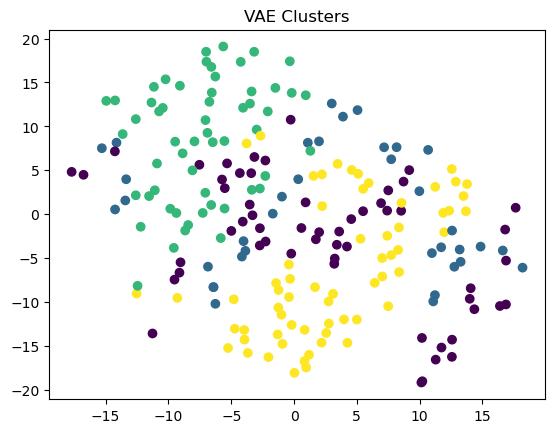

In [30]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=20, random_state=42)

X_vis = tsne.fit_transform(latent)

plt.scatter(X_vis[:,0], X_vis[:,1], c=labels_vae)
plt.title("VAE Clusters")
plt.savefig("../results/latent_visualization/VAE Clusters.png")
plt.show()

In [31]:
import pandas as pd
import os

os.makedirs("../results/latent_visualization", exist_ok=True)

df = pd.DataFrame({
    "Method": ["VAE", "PCA"],
    "Silhouette": [sil_vae, sil_pca],
    "CH Score": [ch_vae, ch_pca]
})

df.to_csv("../results/clustering_metrics.csv", index=False)
